In [22]:
import aster_search_preview as asp

cands = asp.search_aster_granules(
    folha_id="SB21_ZA_II1_NE", # 'SB21_ZA_II1_NE', SB21_XC_V4_SW
    product="AST_07",      # ou "AST_L1T"
    version="004",
    target_date="2008-06-15",
    start_date="2000-01-01",
    end_date="2025-12-31",
    cloud_max=100.0,
    max_items=50,
)

# melhor cena (menor nuvem, data mais próxima)
best = cands[0]

# próxima candidata para comparar
second = cands[1]

print(best["granule_ur"], best["preview_url"])
print(second["granule_ur"], second["preview_url"])


[ASTER] Iniciando search_aster_granules
[ASTER] Autenticando no Earthdata (earthaccess.login)...
[ASTER] folha_id       = SB21_ZA_II1_NE
[ASTER] product        = AST_07.004
[ASTER] bbox (W,S,E,N) = (-56.375, -6.125, -56.25, -6.0)
[ASTER] intervalo      = (2000-01-01, 2025-12-31)
[ASTER] max_items      = 50
[ASTER] cloud_max      = 100.0
[ASTER] Chamando earthaccess.search_data com cloud_hosted=True
[ASTER] kwargs = {'short_name': 'AST_07', 'version': '004', 'bounding_box': (-56.375, -6.125, -56.25, -6.0), 'temporal': ('2000-01-01', '2025-12-31'), 'count': 50, 'cloud_hosted': True}
[ASTER] Granules retornados (cloud_hosted=True): 50
[ASTER] Após leitura de metadata: 50 granules (sem filtro por data/target_date).

Cenas encontradas (ordenadas por nebulosidade crescente):
  [0] id=AST_07_00406222002141408_20250223100330, datetime=2002-06-22T14:14:08.906000+00:00, cloud=0.0, preview=OK
  [1] id=AST_07_00408092002141407_20250225072413, datetime=2002-08-09T14:14:07.638000+00:00, cloud=0.0, p

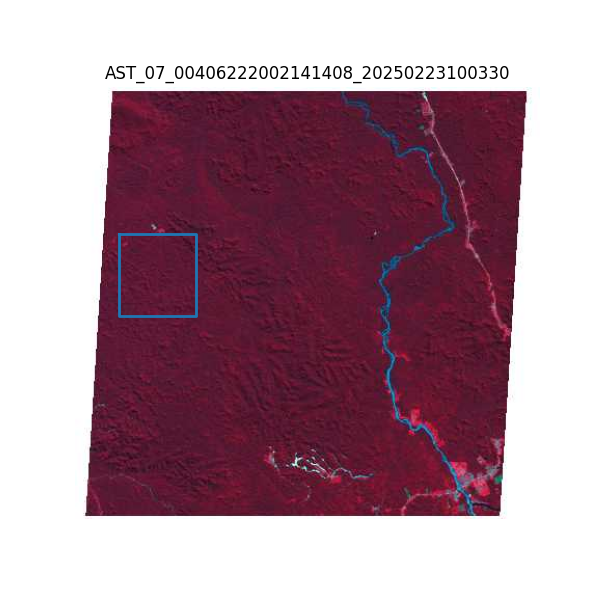

In [27]:
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from shapely.geometry import shape
from db_conn import get_folha_geom_geojson
%matplotlib widget

def _get_granule_bbox_from_umm(umm):
    geom_umm = (
        umm.get("SpatialExtent", {})
           .get("HorizontalSpatialDomain", {})
           .get("Geometry", {})
    )

    rects = geom_umm.get("BoundingRectangles") or geom_umm.get("BoundingRectangle")
    if isinstance(rects, list) and rects:
        r = rects[0]
        west = float(r["WestBoundingCoordinate"])
        east = float(r["EastBoundingCoordinate"])
        south = float(r["SouthBoundingCoordinate"])
        north = float(r["NorthBoundingCoordinate"])
        return west, east, south, north
    elif isinstance(rects, dict):
        west = float(rects["WestBoundingCoordinate"])
        east = float(rects["EastBoundingCoordinate"])
        south = float(rects["SouthBoundingCoordinate"])
        north = float(rects["NorthBoundingCoordinate"])
        return west, east, south, north

    gpolys = geom_umm.get("GPolygons") or geom_umm.get("GPolygon")
    if isinstance(gpolys, list):
        gpoly_list = gpolys
    elif isinstance(gpolys, dict):
        gpoly_list = [gpolys]
    else:
        raise RuntimeError("Nenhuma BoundingRectangle ou GPolygon no UMM.")

    lons, lats = [], []
    for gp in gpoly_list:
        boundary = gp.get("Boundary", {})
        points = boundary.get("Points") or boundary.get("Point") or []
        for p in points:
            lon = p.get("Longitude")
            lat = p.get("Latitude")
            if lon is not None and lat is not None:
                lons.append(float(lon))
                lats.append(float(lat))

    if not lons:
        raise RuntimeError("Não foi possível extrair coordenadas de GPolygons no UMM.")

    west = min(lons)
    east = max(lons)
    south = min(lats)
    north = max(lats)
    return west, east, south, north


def _geom_to_pixel_coords(geom, west, east, south, north, img):
    xs, ys = [], []
    if geom.geom_type == "MultiPolygon":
        polys = geom.geoms
    else:
        polys = [geom]
    for poly in polys:
        for x_lon, y_lat in poly.exterior.coords:
            x_pix = (x_lon - west) / (east - west) * img.width
            y_pix = (north - y_lat) / (north - south) * img.height
            xs.append(x_pix)
            ys.append(y_pix)
        xs.append(None)
        ys.append(None)
    return xs, ys


# -------------------------------------------------------------
# cands já existe; vamos pegar um granule e plotar a folha
# -------------------------------------------------------------
c = cands[0]

# baixar preview
url = c["preview_url"]
resp = requests.get(url)
resp.raise_for_status()
img = Image.open(BytesIO(resp.content))

# bbox do granule (lon/lat)
granule = c["granule"]
umm = granule.get("umm", {})
west, east, south, north = _get_granule_bbox_from_umm(umm)

# geometria da folha em WGS84
folha_id = "SB21_XC_V4_SW"  # ajuste conforme necessário
geom_folha = shape(get_folha_geom_geojson(folha_id))

# converter geometria da folha para pixels
xs, ys = _geom_to_pixel_coords(geom_folha, west, east, south, north, img)

# plot imagem + contorno da folha
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.plot(xs, ys, linewidth=2)
plt.axis("off")
plt.title(c["granule_ur"])
plt.show()


In [31]:
from datetime import datetime, timezone
from typing import Tuple, Dict, Any

import pandas as pd
from pystac_client import Client
import planetary_computer as pc

from db_conn import get_folha_geom_geojson


PC_STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"


def parse_ast07_datetime(ast07_id: str) -> datetime:
    parts = ast07_id.split("_")
    if len(parts) < 3:
        raise ValueError(f"ID AST_07 inesperado: {ast07_id}")

    # Ex.: AST_07_00408092002141407_20250225072413
    version_and_dt = parts[2]          # "00408092002141407"
    if len(version_and_dt) < 3 + 14:
        raise ValueError(f"ID AST_07 inesperado: {ast07_id}")

    dt_str = version_and_dt[3:]        # "08092002141407"
    mm = int(dt_str[0:2])
    dd = int(dt_str[2:4])
    yyyy = int(dt_str[4:8])
    hh = int(dt_str[8:10])
    mi = int(dt_str[10:12])
    ss = int(dt_str[12:14])

    # Coloca o AST_07 explicitamente em UTC (offset-aware)
    return datetime(yyyy, mm, dd, hh, mi, ss, tzinfo=timezone.utc)


def find_best_s2_for_ast07(
    ast07_id: str,
    aoi_geom_geojson: Dict[str, Any],
    cloud_max: float = 5.0,
    s2_start: str = "2015-06-23",
    s2_end: str = "2025-12-31",
    max_items: int = 500,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    ast_dt = parse_ast07_datetime(ast07_id)

    client = Client.open(PC_STAC_URL, modifier=pc.sign_inplace)

    search = client.search(
        collections=["sentinel-2-l2a"],
        intersects=aoi_geom_geojson,
        datetime=f"{s2_start}/{s2_end}",
        query={"eo:cloud_cover": {"lt": cloud_max}},
        max_items=max_items,
    )

    items = list(search.get_items())
    if not items:
        raise RuntimeError(
            f"Sem Sentinel-2 L2A com eo:cloud_cover < {cloud_max} "
            f"no intervalo {s2_start}/{s2_end} para esta AOI."
        )

    rows = []
    for it in items:
        dt = it.datetime  # normalmente datetime UTC (offset-aware)
        if dt is None:
            continue
        cc = it.properties.get("eo:cloud_cover", None)
        delta_days = abs((dt - ast_dt).total_seconds()) / 86400.0
        rows.append(
            {
                "id": it.id,
                "datetime": dt,
                "eo_cloud_cover": cc,
                "delta_days": delta_days,
            }
        )

    if not rows:
        raise RuntimeError("Itens Sentinel-2 retornados, mas nenhum com datetime válido.")

    df = pd.DataFrame(rows).sort_values(["delta_days", "eo_cloud_cover"])
    best_row = df.iloc[0]
    best_item = next(it for it in items if it.id == best_row["id"])

    return df, best_item.to_dict()


if __name__ == "__main__":
    ast07_id = "AST_07_00408092002141407_20250225072413"
    folha_codigo = "SB21_ZA_II2_NE"

    aoi_geom = get_folha_geom_geojson(folha_codigo)

    df_s2, best_s2 = find_best_s2_for_ast07(
        ast07_id=ast07_id,
        aoi_geom_geojson=aoi_geom,
        cloud_max=5.0,
        s2_start="2015-06-23",
        s2_end="2025-12-31",
    )

    print("\n=== Melhor Sentinel-2 para fusão com o AST_07 ===")
    print(f"AST_07: {ast07_id}")
    print(f"Data AST_07: {parse_ast07_datetime(ast07_id).isoformat()}\n")

    print("Melhor Sentinel-2 L2A:")
    print(f"  id         : {best_s2['id']}")
    print(f"  datetime   : {best_s2['properties']['datetime']}")
    print(f"  cloud_cover: {best_s2['properties'].get('eo:cloud_cover')}")
    print("\nTop 10 candidatos:")
    print(df_s2.head(10))



=== Melhor Sentinel-2 para fusão com o AST_07 ===
AST_07: AST_07_00408092002141407_20250225072413
Data AST_07: 2002-08-09T14:14:07+00:00

Melhor Sentinel-2 L2A:
  id         : S2A_MSIL2A_20150819T141046_R110_T21MWP_20210411T230231
  datetime   : 2015-08-19T14:10:46.027000Z
  cloud_cover: 4.707944

Top 10 candidatos:
                                                    id  \
212  S2A_MSIL2A_20150819T141046_R110_T21MWP_2021041...   
210  S2A_MSIL2A_20160724T141052_R110_T21MXP_2021021...   
211  S2A_MSIL2A_20160724T141052_R110_T21MWP_2021021...   
208  S2A_MSIL2A_20170609T141051_R110_T21MXP_2021020...   
209  S2A_MSIL2A_20170609T141051_R110_T21MWP_2021020...   
207  S2B_MSIL2A_20170714T141049_R110_T21MWP_2021021...   
205  S2A_MSIL2A_20170719T141051_R110_T21MXP_2021021...   
206  S2A_MSIL2A_20170719T141051_R110_T21MWP_2021021...   
204  S2B_MSIL2A_20170803T141049_R110_T21MWP_2021021...   
203  S2B_MSIL2A_20170803T141049_R110_T21MXP_2021021...   

                            datetime  eo_c

In [35]:
from datetime import datetime, timezone
from typing import Tuple, Dict, Any, List

import pandas as pd
import xarray as xr
import rioxarray as rxr
from pystac_client import Client
import planetary_computer as pc
import pystac

from db_conn import get_folha_geom_geojson


PC_STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"


def parse_ast07_datetime(ast07_id: str) -> datetime:
    parts = ast07_id.split("_")
    if len(parts) < 3:
        raise ValueError(f"ID AST_07 inesperado: {ast07_id}")
    version_and_dt = parts[2]          # "00408092002141407"
    if len(version_and_dt) < 3 + 14:
        raise ValueError(f"ID AST_07 inesperado: {ast07_id}")
    dt_str = version_and_dt[3:]        # "08092002141407"
    mm = int(dt_str[0:2])
    dd = int(dt_str[2:4])
    yyyy = int(dt_str[4:8])
    hh = int(dt_str[8:10])
    mi = int(dt_str[10:12])
    ss = int(dt_str[12:14])
    return datetime(yyyy, mm, dd, hh, mi, ss, tzinfo=timezone.utc)


def find_best_s2_for_ast07(
    ast07_id: str,
    aoi_geom_geojson: Dict[str, Any],
    cloud_max: float = 5.0,
    s2_start: str = "2015-06-23",
    s2_end: str = "2025-12-31",
    max_items: int = 500,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    ast_dt = parse_ast07_datetime(ast07_id)

    client = Client.open(PC_STAC_URL, modifier=pc.sign_inplace)

    search = client.search(
        collections=["sentinel-2-l2a"],
        intersects=aoi_geom_geojson,
        datetime=f"{s2_start}/{s2_end}",
        query={"eo:cloud_cover": {"lt": cloud_max}},
        max_items=max_items,
    )

    items = list(search.get_items())
    if not items:
        raise RuntimeError(
            f"Sem Sentinel-2 L2A com eo:cloud_cover < {cloud_max} "
            f"no intervalo {s2_start}/{s2_end} para esta AOI."
        )

    rows = []
    for it in items:
        dt = it.datetime
        if dt is None:
            continue
        cc = it.properties.get("eo:cloud_cover", None)
        delta_days = abs((dt - ast_dt).total_seconds()) / 86400.0
        rows.append(
            {
                "id": it.id,
                "datetime": dt,
                "eo_cloud_cover": cc,
                "delta_days": delta_days,
            }
        )

    if not rows:
        raise RuntimeError("Itens Sentinel-2 retornados, mas nenhum com datetime válido.")

    df = pd.DataFrame(rows).sort_values(["delta_days", "eo_cloud_cover"])
    best_row = df.iloc[0]
    best_item = next(it for it in items if it.id == best_row["id"])

    return df, best_item.to_dict()

def load_s2_clip_to_folha(
    s2_item_dict: Dict[str, Any],
    folha_geom: Dict[str, Any],
    bands: List[str] = ("B02", "B03", "B04", "B08", "B11", "B12"),
) -> xr.DataArray:
    import pystac

    item = pystac.Item.from_dict(s2_item_dict)

    # folha_geom já é um GeoJSON de geometria (Polygon/MultiPolygon)
    if folha_geom.get("type") in ("Polygon", "MultiPolygon"):
        geom = folha_geom
    elif folha_geom.get("type") in ("Feature", "FeatureCollection"):
        # fallback genérico, caso no futuro você passe Feature/FeatureCollection
        if folha_geom["type"] == "Feature":
            geom = folha_geom["geometry"]
        else:  # FeatureCollection
            geom = folha_geom["features"][0]["geometry"]
    else:
        raise ValueError(f"Tipo de geometria não suportado: {folha_geom.get('type')}")

    arrays = []
    band_names = []

    for b in bands:
        asset = item.assets.get(b)
        if asset is None:
            continue
        href_signed = pc.sign(asset.href)
        da = rxr.open_rasterio(href_signed, masked=True)
        if "band" in da.dims and da.sizes["band"] == 1:
            da = da.squeeze("band")
        da = da.rio.clip([geom], crs="EPSG:4326", drop=True)
        arrays.append(da)
        band_names.append(b)

    if not arrays:
        raise RuntimeError("Nenhuma banda Sentinel-2 carregada.")

    stacked = xr.concat(arrays, dim="band")
    stacked = stacked.assign_coords(band=("band", band_names))
    return stacked


if __name__ == "__main__":
    ast07_id = "AST_07_00408092002141407_20250225072413"
    folha_codigo = "SB21_ZA_II2_NW"

    aoi_geom = get_folha_geom_geojson(folha_codigo)

    df_s2, best_s2 = find_best_s2_for_ast07(
        ast07_id=ast07_id,
        aoi_geom_geojson=aoi_geom,
        cloud_max=5.0,
        s2_start="2015-06-23",
        s2_end="2025-12-31",
    )

    print("\n=== Melhor Sentinel-2 para fusão com o AST_07 ===")
    print(f"AST_07: {ast07_id}")
    print(f"Data AST_07: {parse_ast07_datetime(ast07_id).isoformat()}")
    print("\nMelhor Sentinel-2 L2A:")
    print(f"  id         : {best_s2['id']}")
    print(f"  datetime   : {best_s2['properties']['datetime']}")
    print(f"  cloud_cover: {best_s2['properties'].get('eo:cloud_cover')}")

    print("\nTop 10 candidatos:")
    print(df_s2.head(10))

    print("\nCarregando e recortando Sentinel-2 para a folha...")
    s2_clip = load_s2_clip_to_folha(best_s2, aoi_geom)
    print(s2_clip)


/home/ggrl/.pyenv/versions/3.13.7/envs/geologia/lib/python3.13/site-packages/pystac_client/item_search.py:925: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(



=== Melhor Sentinel-2 para fusão com o AST_07 ===
AST_07: AST_07_00408092002141407_20250225072413
Data AST_07: 2002-08-09T14:14:07+00:00

Melhor Sentinel-2 L2A:
  id         : S2A_MSIL2A_20150819T141046_R110_T21MWP_20210411T230231
  datetime   : 2015-08-19T14:10:46.027000Z
  cloud_cover: 4.707944

Top 10 candidatos:
                                                    id  \
106  S2A_MSIL2A_20150819T141046_R110_T21MWP_2021041...   
105  S2A_MSIL2A_20160724T141052_R110_T21MWP_2021021...   
104  S2A_MSIL2A_20170609T141051_R110_T21MWP_2021020...   
103  S2B_MSIL2A_20170714T141049_R110_T21MWP_2021021...   
102  S2A_MSIL2A_20170719T141051_R110_T21MWP_2021021...   
101  S2B_MSIL2A_20170803T141049_R110_T21MWP_2021021...   
100  S2A_MSIL2A_20170808T141051_R110_T21MWP_2021021...   
99   S2A_MSIL2A_20180604T141051_R110_T21MWP_2020102...   
98   S2A_MSIL2A_20180614T141051_R110_T21MWP_2020102...   
97   S2A_MSIL2A_20180624T141051_R110_T21MWP_2020101...   

                            datetime  eo_c

/tmp/ipykernel_1735274/1630126576.py:125: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'x' ('x',) The recommendation is to set join explicitly for this case.
  stacked = xr.concat(arrays, dim="band")
/tmp/ipykernel_1735274/1630126576.py:125: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'y' ('y',) The recommendation is to set join explicitly for this case.
  stacked = xr.concat(arrays, dim="band")


In [46]:
s2_clip

<xarray.DataArray (band: 6, y: 2076, x: 2078)> Size: 104MB
array([[[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
        [  nan,   nan,  317., ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,  288., ...,   nan,   nan,   nan]],

       [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
        [  nan,   nan,  534., ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,  501., ...,   nan,   nan,   nan]],

       [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
...
        [  nan,   nan, 3350., ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan, 3216., ...,   nan,   nan,   nan]],

       [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan]],

       [[  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        ...,
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan],
        [  nan,   nan,   nan, ...,   nan,   nan,   nan]]],
      shape=(6, 2076, 2078), dtype=float32)
Coordinates:
  * x            (x) float64 17kB 5.83e+05 5.83e+05 ... 5.968e+05 5.968e+05
  * y            (y) float64 17kB 9.323e+06 9.323e+06 ... 9.337e+06 9.337e+06
    spatial_ref  int64 8B 0
  * band         (band) <U3 72B 'B02' 'B03' 'B04' 'B08' 'B11' 'B12'
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0